In [57]:
# %load_ext autoreload
%reload_ext autoreload
%autoreload 2

import pandas as pd
from eval_helpers import read_dataset, compute_group_variance, plot_computed_results, display_pivoted_results

df = read_dataset("eval_results_all")
# jupyter nbconvert --to html --no-input eval_report.ipynb

Baseline experiment - set up bfcl fc 0/1

In [58]:
# baseline experiment - accuracy
index_cols = ["backend", "wire_api", "fc_model"]
col_cols = ["test_name"]
variance_col = "seed"
metric_col = "correct"
query_filter = "reasoning_effort == 'medium' and test_type != 'gpt_oss'"

group_cols = index_cols + col_cols
out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)

caption = "Table 1: accuracy across backend and wire api x fc_model. Values represent mean ± standard deviation across 8 seeds."

display_pivoted_results(
    df=out,
    index_cols=index_cols,
    col_cols=col_cols,
    metric_col=metric_col,
    precision=4,
    caption=caption
)

In [59]:
# baseline experiment - latency
index_cols = ["backend", "wire_api", "fc_model"]
col_cols = ["test_name"]
variance_col = "seed"
metric_col = "latency"
query_filter = "reasoning_effort == 'medium' and test_type != 'gpt_oss'"

group_cols = index_cols + col_cols
out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)

caption = "Table 2: latency across backend and wire api x fc_model. Values represent mean ± standard deviation across 8 seeds."

display_pivoted_results(
    df=out,
    index_cols=index_cols,
    col_cols=col_cols,
    metric_col=metric_col,
    precision=4,
    caption=caption
)

In [74]:
# baseline experiment - input_token_count
index_cols = ["backend", "wire_api", "fc_model"]
col_cols = ["test_name"]
variance_col = "seed"
metric_col = "input_token_count"
print(df.columns)
query_filter = "reasoning_effort == 'medium' and test_type != 'gpt_oss'"

group_cols = index_cols + col_cols
out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)

caption = "Table 3: input_token_count across backend and wire api x fc_model. Values represent mean ± standard deviation across 8 seeds."

display_pivoted_results(
    df=out,
    index_cols=index_cols,
    col_cols=col_cols,
    metric_col=metric_col,
    precision=4,
    caption=caption
)

Index(['run_name', 'backend', 'wire_api', 'model_name', 'fc_model',
       'browser_enabled', 'python_enabled', 'batch_size', 'seed',
       'reasoning_effort', 'temperature', 'test_id', 'test_name', 'test_type',
       'input_token_count', 'output_token_count', 'latency', 'is_error',
       'correct', 'n_tool_calls_browser', 'n_tool_calls_python'],
      dtype='str')


UnboundLocalError: cannot access local variable 'best_indices' where it is not associated with a value

In [61]:
index_cols = ["backend", "wire_api", "fc_model"]    # Nested Row Headers (The configurations)
col_cols = ["test_name"]    # Column Headers (The benchmark tasks)

variance_col = "seed"
metric_col = "correct"
query_filter = "reasoning_effort == 'medium'"
# query_filter = "backend.str.startswith('burrito', na=False)"

group_cols = index_cols + col_cols

out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)
display_pivoted_results(out, index_cols, col_cols, metric_col)

In [62]:
index_cols = ["backend", "wire_api", "fc_model"]    # Nested Row Headers (The configurations)
col_cols = ["test_name"]    # Column Headers (The benchmark tasks)

variance_col = "seed"
metric_col = "is_error"
query_filter = "reasoning_effort == 'medium'"
# query_filter = "backend.str.startswith('burrito', na=False)"

group_cols = index_cols + col_cols

out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)
display_pivoted_results(out, index_cols, col_cols, metric_col)

In [63]:
index_cols = ["backend", "wire_api", "fc_model"]    # Nested Row Headers (The configurations)
col_cols = ["test_name"]    # Column Headers (The benchmark tasks)

variance_col = "seed"
metric_col = "latency"
query_filter = "reasoning_effort == 'medium'"
# query_filter = "backend.str.startswith('burrito', na=False)"

group_cols = index_cols + col_cols

out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)
display_pivoted_results(out, index_cols, col_cols, metric_col)

In [64]:
index_cols = ["backend", "fc_model", "reasoning_effort", "python_enabled"]    # Nested Row Headers (The configurations)
col_cols = ["test_name"]    # Column Headers (The benchmark tasks)

variance_col = "seed"
metric_col = "correct"
# query_filter = "reasoning_effort == 'medium'"
query_filter = "backend.str.startswith('burrito', na=False) and test_type != 'gpt_oss'"

group_cols = index_cols + col_cols

out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)
display_pivoted_results(out, index_cols, col_cols, metric_col)
display_pivoted_results(out, index_cols, col_cols, metric_col)

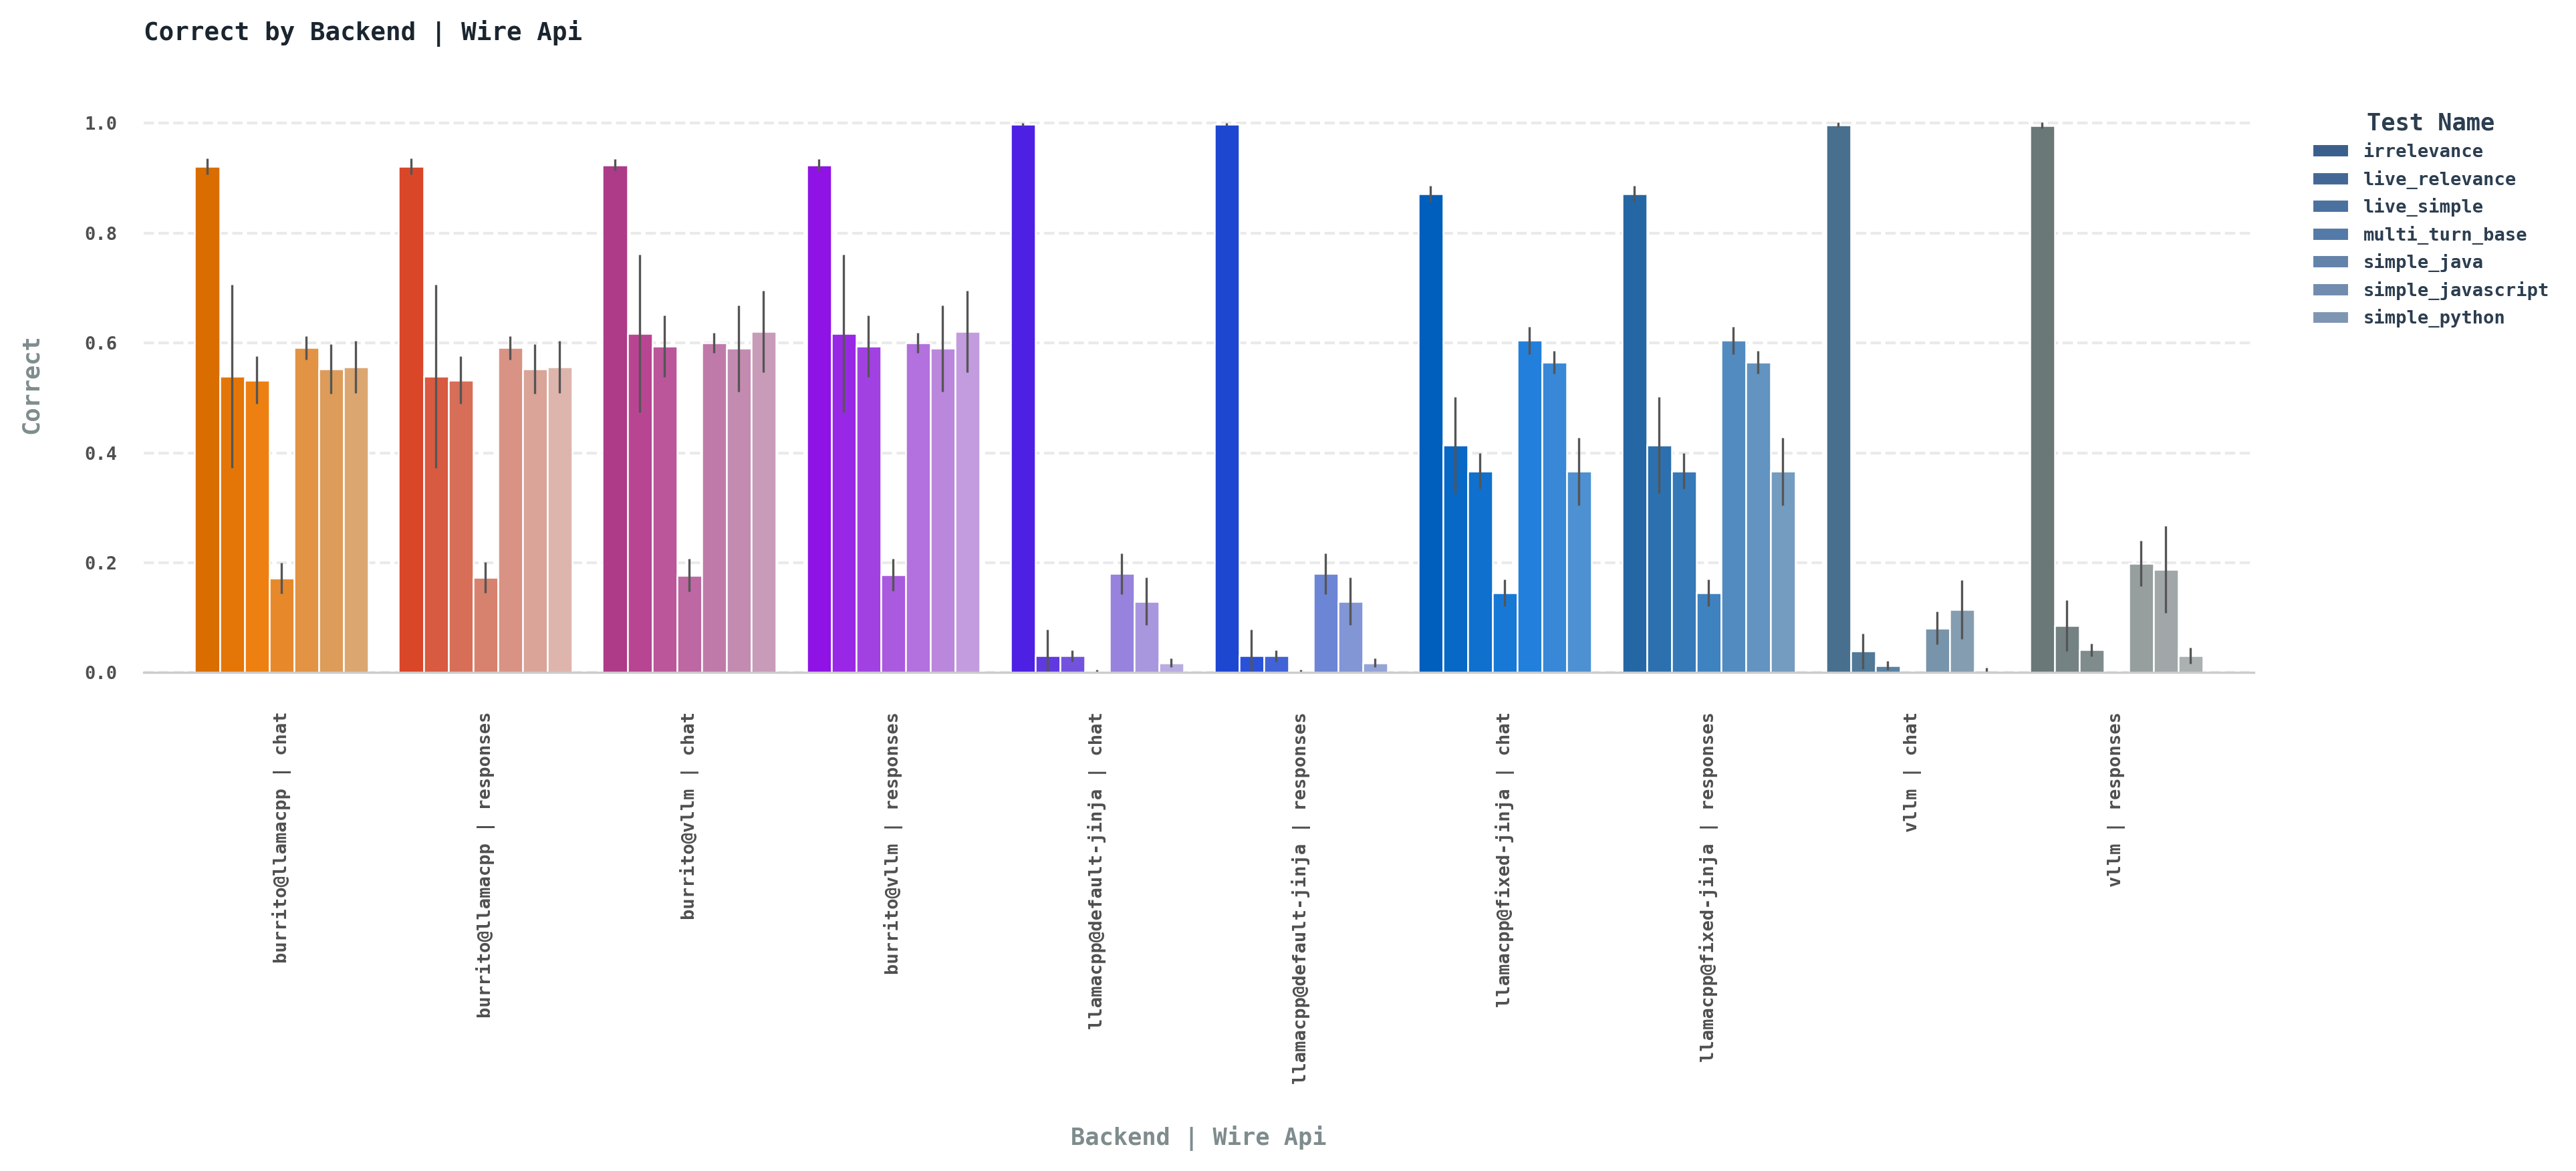

In [65]:
index_cols = ["backend", "wire_api"]    # Nested Row Headers (The configurations)
col_cols = ["test_name"]    # Column Headers (The benchmark tasks)

variance_col = "seed"
metric_col = "correct"
query_filter = "fc_model == 0 and reasoning_effort == 'medium'"
# query_filter = "backend.str.startswith('burrito', na=False)"

group_cols = index_cols + col_cols

out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)
plot_computed_results(out, group_cols, metric_col, plot_type="bar", x_order=None)

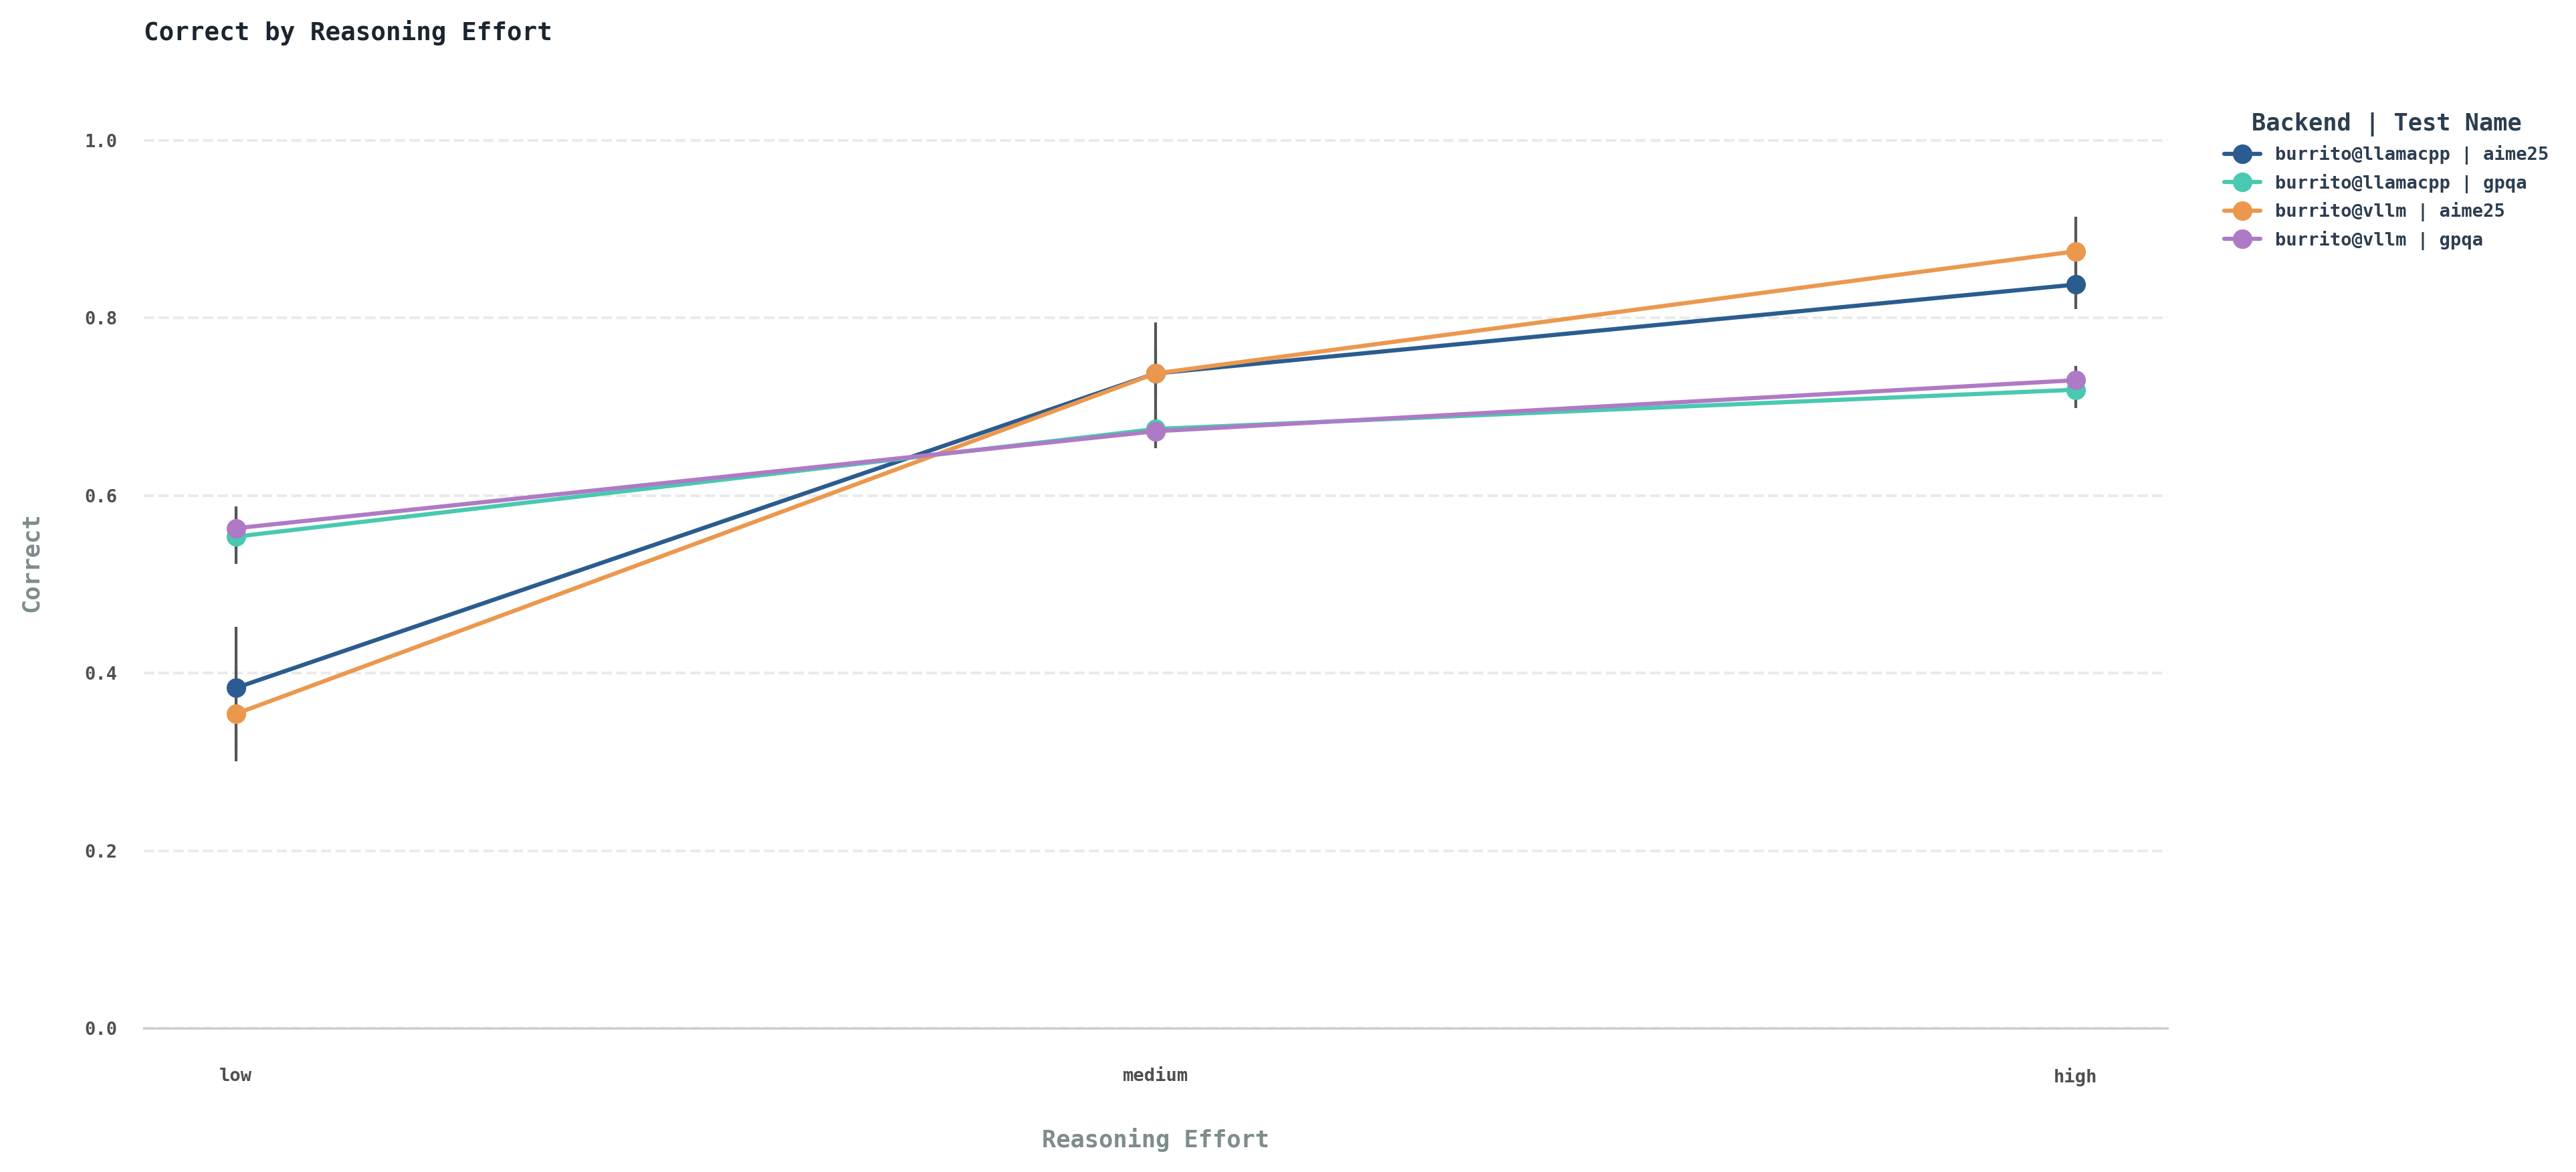

In [66]:
group_cols = ["reasoning_effort", "backend", "test_name"]
variance_col = "seed"
metric_col = "correct"
# query_filter = "reasoning_effort == 'medium'"
query_filter = "test_type == 'gpt_oss' and backend.str.startswith('burrito', na=False) and python_enabled == 0"


out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)
# display_results(out)
plot_computed_results(out, group_cols, metric_col, plot_type="line", x_order=["low", "medium", "high"])